# Stroke Prediction — End to End Machine Learning Pipeline

## Project Overview
Stroke is one of the leading causes of death and long-term disability worldwide. Early identification of individuals at risk can help healthcare professionals take preventive measures and improve patient outcomes. In this project, a machine learning pipeline is developed to predict the likelihood of stroke using demographic, lifestyle, and medical information such as age, hypertension status, heart disease, body mass index (BMI), smoking status, and average glucose level. The goal is to build and evaluate predictive models that can assist in identifying high-risk individuals.

## Problem Statement
Stroke can occur suddenly and often results in severe health complications or death. Many of the risk factors associated with stroke can be identified before the condition occurs. However, accurately assessing an individual's risk using traditional methods can be challenging due to the complex relationships among multiple health factors. Therefore, there is a need for a data-driven approach that can analyze these factors and provide reliable predictions, enabling earlier intervention and better healthcare decision-making.

## Approach
This notebook follows a structured machine learning workflow to develop a stroke prediction model. The process includes:

Understanding and exploring the dataset through exploratory data analysis (EDA).
Cleaning and preprocessing the data by handling missing values, encoding categorical variables, and scaling numerical features where necessary.
Performing feature engineering and feature selection to improve model performance.
Addressing class imbalance in the target variable using appropriate techniques.
Training multiple machine learning models, including Logistic Regression, Random Forest, and XGBoost.
Evaluating model performance using relevant classification metrics such as accuracy, precision, recall, F1-score, ROC-AUC, and confusion matrices.
Selecting the best-performing model and preparing it for deployment or future use.

The final objective is to develop a robust and reliable model capable of predicting stroke risk and supporting preventive healthcare efforts.

## Data Dictionary


 `id`  Unique identifier for each patient — dropped before modeling 

 `gender` Patient gender — Male, Female, or Other

 `age`  Age of the patient in years. Values below 1 represent infants expressed as decimals

 `hypertension` 0 — patient does not have hypertension, 1 — patient has hypertension

 `heart_disease`  0 — patient does not have heart disease, 1 — patient has heart disease

 `ever_married` Whether the patient has ever been married — Yes or No

 `work_type` Type of work — children, govt_job, never_worked, private, or self_employed

 `Residence_type` Type of residence — Rural or Urban

 `avg_glucose_level` Average glucose level in the blood measured in mg/dL

 `bmi` Body Mass Index — weight in kg divided by height in metres squared. 201 missing values

 `smoking_status` Smoking history — formerly smoked, never smoked, smokes, or Unknown
  
 `stroke` Target variable — 1 if the patient had a stroke, 0 if not 

## Dataset
The dataset used in this project is the Stroke Prediction Dataset sourced from Kaggle 
(fedesoriano, 2021). It contains 5,110 patient records with 11 clinical and demographic 
features including age, gender, hypertension, heart disease, marital status, work type, 
residence type, average glucose level, BMI, and smoking status. The target variable is 
a binary indicator of whether the patient experienced a stroke.

Source: https://www.kaggle.com/datasets/fedesoriano/stroke-prediction-dataset

In [6]:
# Importing necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

import sys
import os
sys.path.append(os.path.join(os.path.dirname(os.getcwd()), 'src'))
from cleaning_utilitis import handle_missing, remove_duplicates, fix_dtypes, remove_outliers, clean_strings

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score


### Exploratory Data Analysis

Before cleaning or modelling, the dataset is explored to understand its structure, 
identify missing values, examine the distribution of the target variable, and 
understand the key features.

In [7]:
# Loading dataset
df = pd.read_csv("../data/raw/healthcare-dataset-stroke-data.csv")
df_raw = df.copy()

conn = sqlite3.connect("../data/raw/healthcare-dataset-stroke-data.db")
df.to_sql("stroke", conn, if_exists="replace", index=False)
print("Dataset loaded successfully into an SQLite database.")

Dataset loaded successfully into an SQLite database.


In [8]:
# First Query to check what my data looks like
pd.read_sql_query(
    """
    SELECT *
    FROM stroke
    LIMIT 5;
    """, conn
)

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


The dataset contains demographic, lifestyle, and health-related information for each patient. Features include age, gender, hypertension status, heart disease status, BMI, average glucose level, smoking status, and the target variable (`stroke`).

From the first few records, we can observe that:
- Both numerical and categorical features are present.
- The target variable (`stroke`), hypertension and heart disease are encoded as 0 and 1.
- Missing values are already visible in the `bmi` column.

In [9]:
pd.read_sql_query("""
        SELECT AVG(age) AS average_age, CASE WHEN stroke = 1 THEN 'Stroke' ELSE 'No Stroke' END AS stroke_status
        FROM stroke
        GROUP BY stroke;
        """, conn)

,average_age,stroke_status
0,41.971545,No Stroke
1,67.728193,Stroke


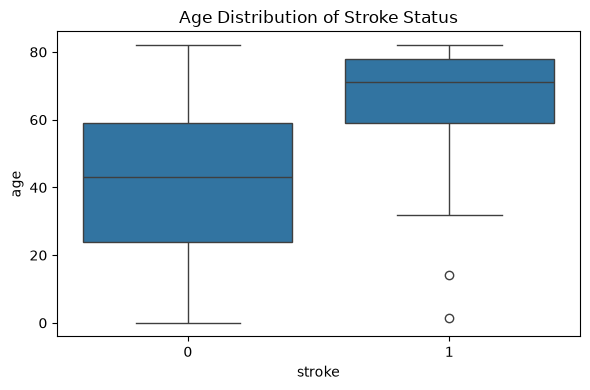

In [10]:
# visualizing the distribution of age across stroke status
plt.figure(figsize=(6, 4))
sns.boxplot(x="stroke", y="age", data=df)
plt.title("Age Distribution of Stroke Status")
plt.savefig("../outputs/figures/age_distribution_of_stroke_status.png", dpi=150, bbox_inches='tight')
plt.tight_layout()
plt.show()



The query shows that the average age of stroke patients is approximately 68 years, while non-stroke patients have an average age of about 42 years. Further visualisation showed Stroke patients are considerably older on average than non-stroke patients, suggesting age is a strong predictor of stroke risk.

In [11]:
pd.read_sql_query("""
    SELECT AVG(avg_glucose_level), CASE WHEN stroke = 1 THEN 'Stroke' ELSE 'No Stroke' END AS stroke_status
    FROM stroke
    GROUP BY stroke;
    """, conn)

,AVG(avg_glucose_level),stroke_status
0,104.795513,No Stroke
1,132.544739,Stroke


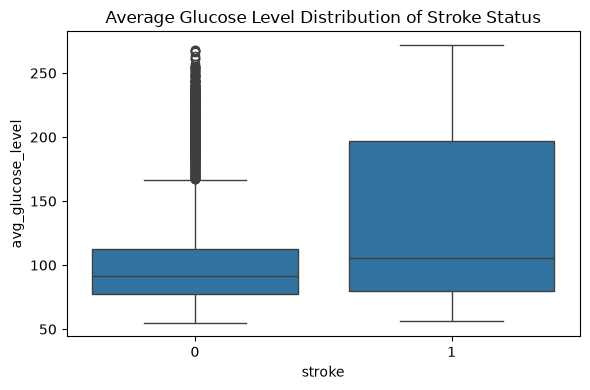

In [12]:
# visualizing the distribution of average glucose level across stroke status
plt.figure(figsize=(6, 4))
sns.boxplot(x="stroke", y="avg_glucose_level", data=df)
plt.title("Average Glucose Level Distribution of Stroke Status")
plt.savefig("../outputs/figures/avg_glucose_level_distribution_of_stroke_status.png", dpi=150, bbox_inches='tight')
plt.tight_layout()
plt.show()

The analysis shows that patients who experienced a stroke have a substantially higher average glucose level (132.54) compared to patients who did not (104.80). This suggests a positive association between elevated glucose levels and stroke occurrence.

The boxplot further supports this observation, showing a higher median glucose level among stroke patients. In addition, the glucose distribution for the stroke group exhibits a wider spread, indicating greater variability in glucose levels among individuals who experienced a stroke.

Although some overlap exists between the two groups, stroke patients generally tend to have higher glucose levels. This suggests that average glucose level may be a useful predictor in the stroke prediction model.

In [13]:
# querying to check between gender who has the higher stroke percentage
pd.read_sql_query(
    """
    SELECT gender, 
        COUNT(*) AS total_count, 
        COUNT(CASE WHEN stroke = 1 THEN 1 END) AS stroke_count, 
        ROUND(COUNT(CASE WHEN stroke = 1 THEN 1 END) * 100.0 / COUNT(*), 2) AS stroke_percentage
    FROM stroke
    WHERE gender IN ('Male', 'Female')
    GROUP BY gender;
    """, conn)

,gender,total_count,stroke_count,stroke_percentage
0,Female,2994,141,4.71
1,Male,2115,108,5.11


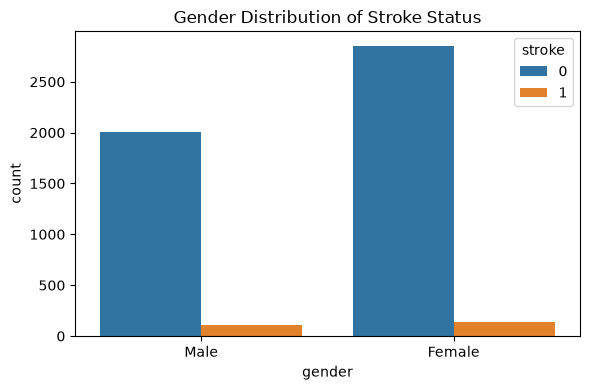

In [14]:
# visualizing 
df_clean = df[df['gender'] != 'Other']

plt.figure(figsize=(6, 4))
sns.countplot(data=df_clean, x='gender', hue='stroke')
plt.title("Gender Distribution of Stroke Status")
plt.tight_layout()
plt.savefig("../outputs/figures/gender_distribution_of_stroke_status.png", dpi=150, bbox_inches='tight')
plt.show()

Males exhibit a slightly higher stroke percentage than females in this dataset. However, the difference is small, suggesting that gender alone may not be a strong predictor of stroke compared to factors such as age, hypertension, or heart disease.
Although the visualisation shows a higher number of stroke cases among females, this is misleading because the dataset is imbalanced in terms of total counts (females: 2,994; males: 2,115). For this reason, comparing percentages provides a more accurate understanding than raw counts.

In [15]:
# querying the data to get insights on lifestyle(smoking_status) on stroke status
pd.read_sql_query("""
    SELECT smoking_status,
    COUNT(*) AS total_counts,
    COUNT(CASE WHEN stroke = 1 THEN 1 END) AS stroke_count,
    ROUND(COUNT(CASE WHEN stroke = 1 THEN 1 END) * 100.0 / COUNT(*), 2) AS stroke_percentage
    FROM stroke
    GROUP BY smoking_status;
    """, conn)

,smoking_status,total_counts,stroke_count,stroke_percentage
0,Unknown,1544,47,3.04
1,formerly smoked,885,70,7.91
2,never smoked,1892,90,4.76
3,smokes,789,42,5.32


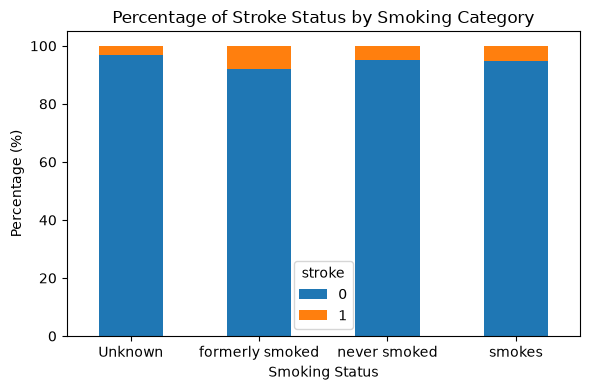

In [16]:
# visualising
df_perc = pd.crosstab(df['smoking_status'], df['stroke'], normalize='index') * 100

df_perc.plot(kind='bar', stacked=True, figsize=(6, 4))
plt.title("Percentage of Stroke Status by Smoking Category")
plt.ylabel("Percentage (%)")
plt.xlabel("Smoking Status")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("../outputs/figures/smoking_status_distribution_of_smoking_status.png", dpi=150, bbox_inches='tight')
plt.show()

In [17]:
df_age = df.groupby('smoking_status')['age'].mean()
df_age

smoking_status
Unknown            30.229922
formerly smoked    54.929944
never smoked       46.744715
smokes             47.096324
Name: age, dtype: float64



The query shows that individuals who formerly smoked have the highest percentage of stroke cases, followed by those who currently smoke. This suggests a possible association between smoking history and stroke occurrence. Both current and former smokers appear to have higher stroke prevalence compared to non-smokers, indicating that smoking may be a relevant risk factor for stroke in this dataset; however, age acts as a major confounding variable here, as the "formerly smoked" group skews significantly older (average age of 55) than the other categories.

In [18]:
pd.read_sql_query("""
   SELECT
    stroke,
    AVG(bmi) AS average_bmi,
    COUNT(*) AS total_count
FROM stroke
GROUP BY stroke;
    """, conn
    )

,stroke,average_bmi,total_count
0,0,28.823064,4861
1,1,30.471292,249


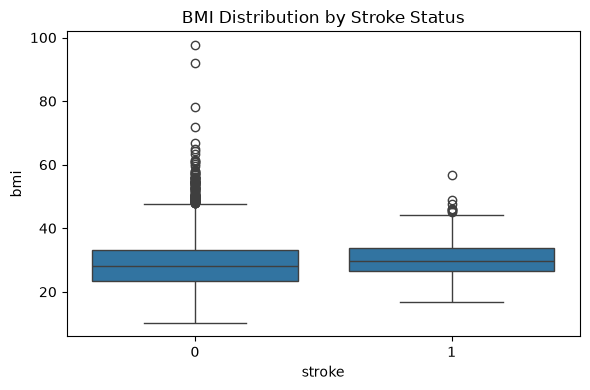

In [19]:
plt.figure(figsize=(6, 4))

sns.boxplot(x="stroke", y="bmi", data=df)
plt.title("BMI Distribution by Stroke Status")
plt.tight_layout()
plt.savefig("../outputs/figures/bmi_distribution_of_stroke_status.png", dpi=150, bbox_inches='tight')
plt.show()

The analysis shows that patients who experienced a stroke have a slightly higher average BMI compared to those who did not. However, the difference is modest, suggesting that BMI alone is not a strong discriminator between the two groups.

This is further supported by the boxplot, which shows substantial overlap in BMI distributions across both classes, indicating limited separation power. While BMI may contribute some predictive value, it is likely more useful when combined with other risk factors such as age and average glucose level.

Additionally, the non-stroke group exhibits a wider range of extreme BMI values, including several outliers, suggesting greater variability in BMI among individuals without stroke.

In [20]:
pd.read_sql_query("""
   SELECT hypertension,
       COUNT(*) AS total_counts,
       SUM(stroke) AS stroke_patients,
       ROUND(SUM(stroke) * 100.0 / COUNT(*), 2) AS stroke_percentage
    FROM stroke
    GROUP BY hypertension;
   """, conn) 

,hypertension,total_counts,stroke_patients,stroke_percentage
0,0,4612,183,3.97
1,1,498,66,13.25


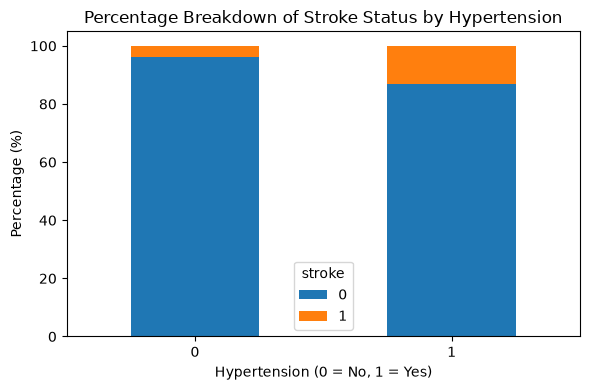

In [21]:
hypertension_stroke_pct = pd.crosstab(df["hypertension"], df["stroke"], normalize="index") * 100

hypertension_stroke_pct.plot(
    kind="bar", stacked=True, figsize=(6, 4)
)

plt.title("Percentage Breakdown of Stroke Status by Hypertension")
plt.xlabel("Hypertension (0 = No, 1 = Yes)")
plt.ylabel("Percentage (%)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("../outputs/figures/hypertension_vs_stroke_stacked.png", bbox_inches="tight")
plt.show()

The data in this dataset reveals that individuals with hypertension have a substantially higher stroke rate of 13.25% (66 out of 498 patients) compared to just 3.97% (183 out of 4,612 patients) for those without it, confirming high blood pressure as a major risk factor while highlighting a clear baseline class imbalance.

In [22]:
pd.read_sql_query("""
   SELECT heart_disease,
       COUNT(*) AS total_counts,
       SUM(stroke) AS stroke_patients,
       ROUND(SUM(stroke) * 100.0 / COUNT(*), 2) AS stroke_percentage
    FROM stroke
    GROUP BY heart_disease;
   """, conn) 

,heart_disease,total_counts,stroke_patients,stroke_percentage
0,0,4834,202,4.18
1,1,276,47,17.03


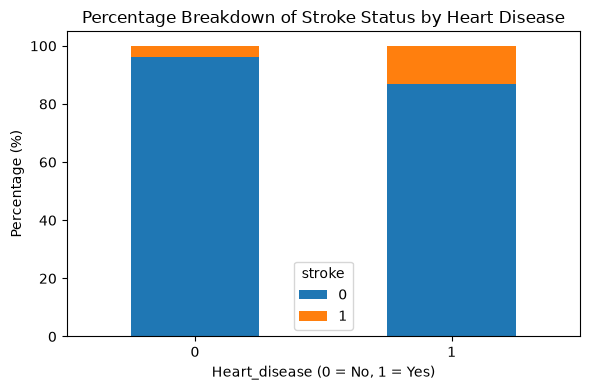

In [23]:
heart_disease_stroke_pct = pd.crosstab(df["heart_disease"], df["stroke"], normalize="index") * 100

hypertension_stroke_pct.plot(kind="bar", stacked=True, figsize=(6, 4))

plt.title("Percentage Breakdown of Stroke Status by Heart Disease")
plt.xlabel("Heart_disease (0 = No, 1 = Yes)")
plt.ylabel("Percentage (%)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("../outputs/figures/heart_disease_vs_stroke_stacked.png", bbox_inches="tight")
plt.show()

The Data in this dataset demonstrates a strong association between cardiovascular health and stroke risk, showing that individuals with heart disease experience a dramatically higher stroke rate of 17.03% (47 out of 276 patients) compared to just 4.18% (202 out of 4,834 patients) for those without it.

This step helps us understand the dataset size (rows and columns) and inspect the data types of each feature to ensure everything is correctly formatted before further analysis.

In [24]:
print(df.shape)
df.info()

(5110, 12)
<class 'pandas.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   str    
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   str    
 6   work_type          5110 non-null   str    
 7   Residence_type     5110 non-null   str    
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   str    
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), str(5)
memory usage: 479.2 KB


The dataset contains 5,110 patient records and 12 columns. The BMI column has 
201 missing values (4909 non-null out of 5110). All other columns are complete. 
The id column will be dropped before modeling as it carries no predictive value. 
Data types appear correct with numeric columns either stored as float64 or int64, and categorical 
columns are stored as strings.

In [25]:
df.describe()

,id,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke
count,5110.000000,5110.000000,5110.000000,5110.000000,5110.000000,4909.000000,5110.000000
mean,36517.829354,43.226614,0.097456,0.054012,106.147677,28.893237,0.048728
std,21161.721625,22.612647,0.296607,0.226063,45.283560,7.854067,0.215320
min,67.000000,0.080000,0.000000,0.000000,55.120000,10.300000,0.000000
25%,17741.250000,25.000000,0.000000,0.000000,77.245000,23.500000,0.000000
50%,36932.000000,45.000000,0.000000,0.000000,91.885000,28.100000,0.000000
75%,54682.000000,61.000000,0.000000,0.000000,114.090000,33.100000,0.000000
max,72940.000000,82.000000,1.000000,1.000000,271.740000,97.600000,1.000000


The statistical summary is essential because it provides an immediate baseline audit of data integrity, highlighting missing values, extreme outliers, feature distributions, and severe class imbalances that dictate how data is cleaned and modeling strategies.

In [26]:
# checking for missing values

missing_values = df.isnull().sum()
print(missing_values[missing_values>0])

bmi    201
dtype: int64


Only the BMI column has missing values (201 records, approximately 4% of the dataset). 
This is a relatively small proportion and will be handled by imputation rather than 
dropping rows, since removing 201 rows would reduce an already small dataset further. 
The imputation strategy will be decided after examining the BMI distribution.

In [27]:
# checking the target distribution
df['stroke'].value_counts()
df['stroke'].value_counts(normalize=True).round(3)

stroke
0    0.951
1    0.049
Name: proportion, dtype: float64

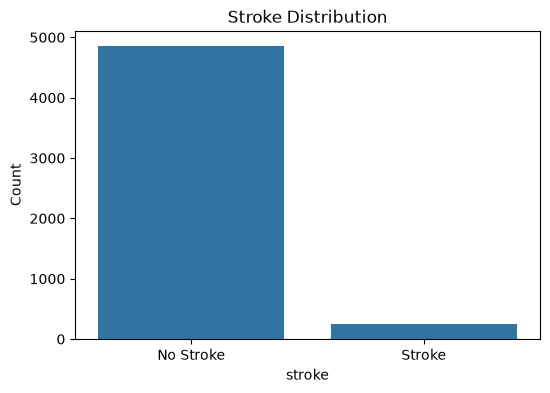

In [28]:
# plotting target distribution
plt.figure(figsize=(6,4))
sns.countplot(x='stroke', data=df)
plt.title("Stroke Distribution")
plt.xticks([0, 1], ['No Stroke', 'Stroke'])
plt.ylabel('Count')
plt.savefig('../outputs/figures/stroke_distribution.png', dpi=150, bbox_inches='tight')
plt.show()


The target variable is heavily imbalanced: about 95.1% of patients did not have a stroke, while only 4.9% did. This means a naive model that always predicts “no stroke” could still achieve around 95% accuracy, even though it would be clinically useless. Because of this imbalance, it’s important to handle it during modeling using techniques such as class weights, SMOTE, or threshold tuning so the model can better detect actual stroke cases.

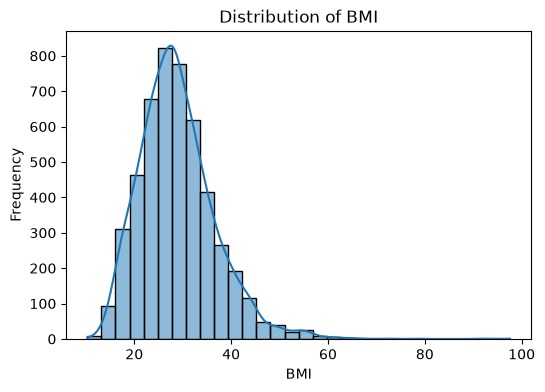

In [29]:
# Key feature distribution: BMI

plt.figure(figsize=(6, 4))
sns.histplot(df["bmi"], bins=30, kde=True)
plt.title("Distribution of BMI")
plt.xlabel("BMI")
plt.ylabel("Frequency")
plt.savefig('../outputs/figures/bmi_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

BMI follows an approximately normal distribution with a slight right skew, centered 
around 25-30. A small number of extreme high values are visible above 60 which will 
be investigated as potential outliers. Since the distribution is roughly symmetric, 
median imputation will be used to fill the 201 missing values.

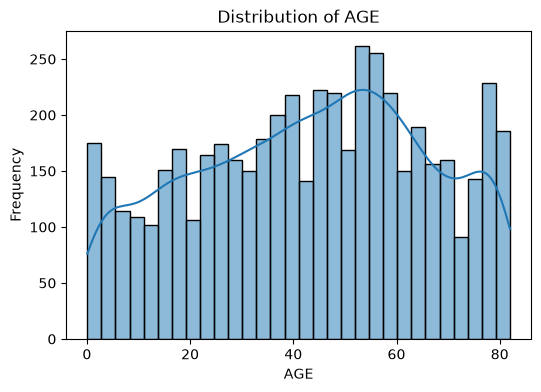

In [30]:
# Key feature distribution: AGE

plt.figure(figsize=(6, 4))
sns.histplot(df["age"], bins=30, kde=True)
plt.title("Distribution of AGE")
plt.xlabel("AGE")
plt.ylabel("Frequency")
plt.savefig('../outputs/figures/age_distribution.png', dpi=150, bbox_inches='tight')

plt.show()

The age distribution is fairly uniform across all age groups from 0 to 82, with a 
slight peak around 50-60 years. Stroke risk is expected to increase with age which will be 
captured through age group binning in feature engineering.

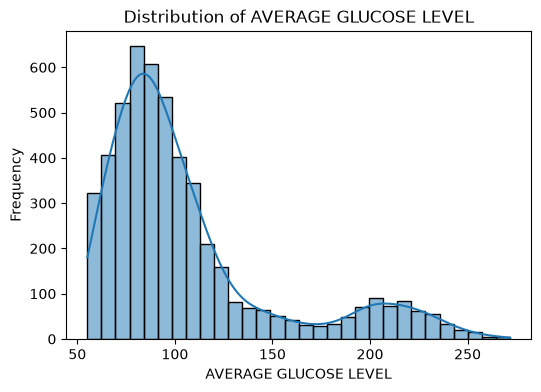

In [31]:
# Key feature distribution: AVERAGE GLUCOSE LEVEL

plt.figure(figsize=(6,4))
sns.histplot(df["avg_glucose_level"], bins=30, kde=True)
plt.title("Distribution of AVERAGE GLUCOSE LEVEL")
plt.xlabel("AVERAGE GLUCOSE LEVEL")
plt.ylabel("Frequency")
plt.savefig('../outputs/figures/avg_glu_level_distribution.png', dpi=150, bbox_inches='tight')

plt.show()



The glucose distribution exhibits a bimodal pattern, with one peak representing normal glucose levels and another representing elevated glucose levels. This supports earlier findings that stroke patients tend to have higher glucose levels and suggests that elevated glucose may be an important risk factor associated with stroke occurrence.

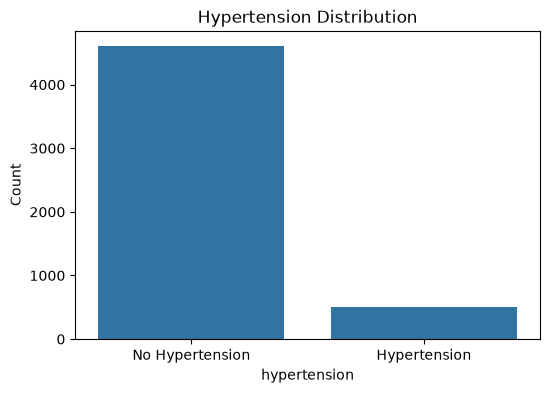

In [32]:
# Key feature distribution: HYPERTENSION
plt.figure(figsize=(6,4))
sns.countplot(x='hypertension', data=df)
plt.title("Hypertension Distribution")
plt.xticks([0, 1], ['No Hypertension', 'Hypertension'])
plt.ylabel('Count')
plt.savefig('../outputs/figures/hypertension_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

The majority of patients, approximately 90% do not have hypertension. Only a small 
proportion have hypertension. Despite this imbalance within the feature itself, 
hypertension is a known clinical risk factor for stroke and will be retained as a 
feature. It will also be combined with heart disease to create a cardiovascular risk 
score in feature engineering.

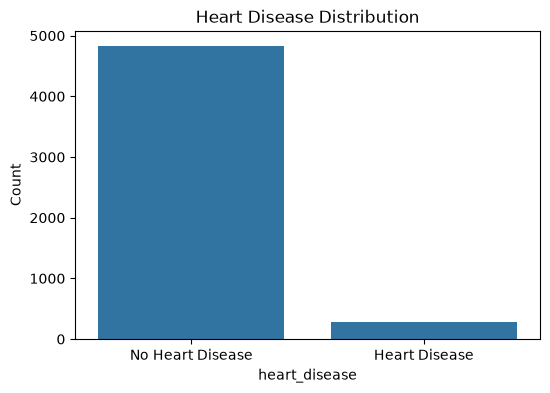

In [33]:
# Key feature distribution: HEART DISEASE
plt.figure(figsize=(6,4))
sns.countplot(x='heart_disease', data=df)
plt.title("Heart Disease Distribution")
plt.xticks([0, 1], ['No Heart Disease', 'Heart Disease'])
plt.ylabel('Count')
plt.savefig('../outputs/figures/heart_disease_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

Similar to hypertension, heart disease is present in a small minority of patients. 
The overwhelming majority have no recorded heart disease. Like hypertension, this 
binary feature carries important clinical significance for stroke prediction and will 
be retained. The combination of both hypertension and heart disease into a single 
cardiovascular risk feature will help capture compounded risk in patients with both 
conditions.

### Data Cleaning



Prior to modeling, raw datasets must undergo Exploratory Data Analysis and cleaned to handle structural inconsistencies, and ensure high data integrity. Initial inspection of the dataset via `df.describe()` has already revealed that the `bmi` feature contains **201 missing values** (4,909 non-null records out of 5,110 entries). 

The following pipeline will systematically address these missing entries, isolate extreme outliers, and standardize data types to prepare the dataset for machine learning.

In [34]:
# filling missing values in BMI column
instructions = {
    'bmi':'median'
}
df = handle_missing(df, instructions, fill_value=None)



We selected **median imputation** over mean imputation to handle the 201 missing values in the `bmi` feature. As established during EDA, the `bmi` distribution is heavily right-skewed with extreme upper outliers (stretching to a maximum value of 97.6, while the 75th percentile sits at 33.1). Using the mean in a skewed distribution will pull the imputed values upward, artificially distorting the feature's variance. 

In [35]:
# checking if there is still any missing value

missing_values = df.isnull().sum()
missing_values[missing_values>0]
print("There are no more missing values. ")

There are no more missing values. 


In [36]:
# checking for and removing duplicates rows
df = remove_duplicates(df)

Removed 0 duplicate rows — 5110 rows remaining


There was no duplicate rows in our dataset.

In [37]:
# dropping the ID column

df = df.drop("id", axis=1)

The ID column was dropped because it does not help prediction and might just introduce noise.
The `id` column was removed because it serves only as a unique identifier for each patient and does not contain information relevant to stroke prediction, Including such identifiers can introduce noise into the model without contributing meaningful predictive value.

In [38]:
df['gender'].value_counts()

gender
Female    2994
Male      2115
Other        1
Name: count, dtype: int64

In [39]:
df = df[df["gender"] != "Other"]
df = df.reset_index(drop=True)

In [40]:
df["gender"].value_counts()

gender
Female    2994
Male      2115
Name: count, dtype: int64

During the initial data exploration, the `gender` feature revealed three unique categories: `Female`, `Male`, and `Other`. Further analysis showed that the `Other` category consists of **only a single record** out of 5,110 entries. 

The decision was made for it to be dropped, Because a single observation provides zero statistical significance and insufficient variance for machine learning algorithms to learn from. 

In [41]:
df["bmi"].describe()

count    5109.000000
mean       28.863300
std         7.699785
min        10.300000
25%        23.800000
50%        28.100000
75%        32.800000
max        97.600000
Name: bmi, dtype: float64

In [42]:
df["bmi"].quantile([0.95, 0.99, 0.995, 0.999])

0.950    42.6600
0.990    52.8920
0.995    55.9000
0.999    64.7568
Name: bmi, dtype: float64

The statistical summary of BMI shows that there are outliers with the 75th percentile being `32.8` and the max being `97.6`. The gap is huge and suggests the presence of outliers. Further analysis was done.
The `bmi` contains a small number of extreme observations. The 99th percentile BMI is 52.89, while a few records exceed 70. Although these values are statistically outlying, they remain within the range of medically plausible BMI measurements and were therefore retained. Their impact on model performance will be assessed during feature engineering and model evaluation.

In [43]:
# cleaning strings

df = clean_strings(df)

Cleaned 5 string column(s)


String cleaning standardizes text data by removing trailing whitespaces, normalizing letter cases, and fixing typos, preventing computers from treating identical categories as entirely separate values.

In [44]:
# saving the cleaned dataset
df.to_csv("../data/processed/stroke_cleaned.csv", index=False)

### Feature Engineering and Encoding

New features are created from existing columns to capture relationships 
that raw features alone cannot express. 

In [45]:
# Feature engineering: Binning continous columns like age, avg glucose level and bmi, which are likely strong predicctors of stroke as they increase
df['age_group'] = pd.cut(df['age'], bins=[0, 18, 41, 65, np.inf], labels=['Child', 'Young_adult', 'Adult', 'Elderly'])
df['glucose_group'] = pd.cut(df['avg_glucose_level'], bins=[0, 70, 100, 126, np.inf], labels=['Low', 'Normal', 'Prediabetic', 'Diabetic'])
df['bmi_group'] = pd.cut(df['bmi'], bins=[0, 18.5, 25, 30, float('inf')], labels=['Underweight', 'Normal', 'Overweight', 'Obese'])



In [46]:
df.groupby('age_group')['stroke'].mean().sort_values()

age_group
Child          0.002183
Young_adult    0.004286
Adult          0.046499
Elderly        0.161658
Name: stroke, dtype: float64

**stroke prevalence increases with age**.  
- Children have the lowest stroke rate (~0.2%).  
- Young adults show slightly higher risk (~0.4%).  
- Adults see a noticeable increase (~4.6%).  
- Elderly individuals have the highest stroke prevalence (~16.2%).  

This confirms that **age is a strong risk factor for stroke**, with risk rising steadily across age groups. And would be mapped in that corresponding order.

In [47]:
df.groupby('bmi_group')['stroke'].mean().sort_values()

bmi_group
Underweight    0.002865
Normal         0.029435
Obese          0.050713
Overweight     0.071429
Name: stroke, dtype: float64

Contrary to clinical assumption, overweight patients show a higher stroke rate 
(7.14%) than obese patients (5.07%) in this dataset. The BMI risk mapping therefore 
reflects actual observed stroke rates rather than assumed clinical order. Underweight 
patients show the lowest stroke rate at 0.29% and are assigned a score of 0.

In [48]:
# Feature engineering: Combining two features to create an interaction feature
age_map = {'Child': 0, 'Young_adult': 1, 'Adult': 2, 'Elderly': 3}
bmi_map = {'Underweight': 0, 'Normal':1, 'Overweight': 3, 'Obese': 2}

df['age_bmi_risk'] = df['age_group'].map(age_map).astype(int) + df['bmi_group'].map(bmi_map).astype(int)

# combining both heart disease and hypertension to show greater risk than just summing both
df['combined_condition'] = (
    (df['hypertension'] == 1) & (df["heart_disease"] == 1)
).astype(int)

In [49]:
df['combined_condition'].value_counts()

combined_condition
0    5045
1      64
Name: count, dtype: int64

In [50]:
df.groupby('combined_condition')['stroke'].mean()

combined_condition
0    0.046779
1    0.203125
Name: stroke, dtype: float64

Patients with both hypertension and heart disease simultaneously show a stroke rate 
of 20.3% compared to 4.7% for all other patients which is over 4 times higher risk. 
This combined condition flag captures a compounded cardiovascular risk that neither 
feature alone expresses. Simple addition of the two binary columns was rejected 
because it implies equal weighting and additive risk, whereas the clinical evidence 
in this dataset suggests the simultaneous presence of both conditions creates a 
disproportionately higher risk category.

In [51]:
df.groupby('smoking_status')['stroke'].mean()

smoking_status
formerly smoked    0.079186
never smoked       0.047569
smokes             0.053232
unknown            0.030440
Name: stroke, dtype: float64

In [52]:
# Feature engineering: collapsing smoking status category to draw insghts from the raw data

df['ever_smoked'] = df['smoking_status'].apply(
    lambda x: 1 if x in ['formerly smoked', 'smokes'] else 0
)


In [53]:
# checking the stroke of the newly engineered feature
df.groupby('ever_smoked')['stroke'].mean()

ever_smoked
0    0.039872
1    0.066946
Name: stroke, dtype: float64

Smoking status is transformed into a binary feature capturing whether a patient 
has ever been exposed to smoking, either currently or formerly. This is motivated 
by the data showing formerly smoked patients have the highest stroke rate at 7.9%, 
higher than current smokers at 5.3%, suggesting cumulative exposure matters more 
than current status. Unknown is treated as never smoked for this feature.

In [54]:
# checking the data types to pick columns that needs to be encoded
df.dtypes

gender                     str
age                    float64
hypertension             int64
heart_disease            int64
ever_married               str
work_type                  str
Residence_type             str
avg_glucose_level      float64
bmi                    float64
smoking_status             str
stroke                   int64
age_group             category
glucose_group         category
bmi_group             category
age_bmi_risk             int64
combined_condition       int64
ever_smoked              int64
dtype: object

In [55]:
# printing the ordinal columns unique values so as to know how to map properly
print(df['age_group'].unique())
print(df['bmi_group'].unique())
print(df['glucose_group'].unique())

['Elderly', 'Adult', 'Young_adult', 'Child']
Categories (4, str): ['Child' < 'Young_adult' < 'Adult' < 'Elderly']
['Obese', 'Overweight', 'Normal', 'Underweight']
Categories (4, str): ['Underweight' < 'Normal' < 'Overweight' < 'Obese']
['Diabetic', 'Prediabetic', 'Normal', 'Low']
Categories (4, str): ['Low' < 'Normal' < 'Prediabetic' < 'Diabetic']


In [56]:
# Encoding categorical columns using binary encoding, OHE and ordinal encoding

df["gender"] = df["gender"].map({"female":0, "male":1})
df["Residence_type"] = df["Residence_type"].map({"urban":0, "rural":1})
df["ever_married"] = df["ever_married"].map({"no":0, "yes":1})

ohe_columns = ["work_type", "smoking_status"]

df = pd.get_dummies(df, columns=ohe_columns, dtype=int)

age_mapping = {"Child" : 0, "Young_adult" : 1, "Adult" : 2, "Elderly" : 3}
bmi_mapping = {"Underweight" : 0, "Normal" : 1, "Obese": 2, "Overweight" : 3}
glucose_mapping = {"Low" : 0, "Normal" : 1, "Prediabetic" : 2, "Diabetic" : 3}

df["age_group"] = df["age_group"].map(age_mapping).astype(int)
df["bmi_group"] = df["bmi_group"].map(bmi_mapping).astype(int)
df["glucose_group"] = df["glucose_group"].map(glucose_mapping).astype(int)




Different encoding techniques were applied based on the characteristics of each categorical variable:

- **Binary Encoding (0/1 Mapping)** was used for `gender`, `Residence_type`, and `ever_married` because these features contain only two categories. Mapping them to 0 and 1 is simple and preserves all information.

- **One-Hot Encoding (OHE)** was used for `work_type` and `smoking_status` because these features have multiple categories with no natural order. OHE prevents the model from assuming that one category is greater than another.

- **Ordinal Encoding** was used for `age_group`, `bmi_group`, and `glucose_group` because these categories have a meaningful progression. Assigning increasing numerical values preserves the inherent order of the categories. For `bmi_group`, the ordinal mapping follows observed stroke rates in the data 
rather than standard clinical BMI categories. Overweight patients showed a higher 
stroke rate (7.14%) than obese patients (5.07%), so overweight was assigned a 
higher ordinal value to reflect actual risk in this dataset.

In [57]:
# checking to see if they're all encoded
print(df.dtypes)
df.sample(3)

gender                              int64
age                               float64
hypertension                        int64
heart_disease                       int64
ever_married                        int64
Residence_type                      int64
avg_glucose_level                 float64
bmi                               float64
stroke                              int64
age_group                           int64
glucose_group                       int64
bmi_group                           int64
age_bmi_risk                        int64
combined_condition                  int64
ever_smoked                         int64
work_type_children                  int64
work_type_govt_job                  int64
work_type_never_worked              int64
work_type_private                   int64
work_type_self-employed             int64
smoking_status_formerly smoked      int64
smoking_status_never smoked         int64
smoking_status_smokes               int64
smoking_status_unknown            

,gender,age,hypertension,heart_disease,ever_married,Residence_type,avg_glucose_level,bmi,stroke,age_group,glucose_group,bmi_group,age_bmi_risk,combined_condition,ever_smoked,work_type_children,work_type_govt_job,work_type_never_worked,work_type_private,work_type_self-employed,smoking_status_formerly smoked,smoking_status_never smoked,smoking_status_smokes,smoking_status_unknown
3331,1,27.0,0,0,1,0,114.32,28.1,0,1,2,3,4,0,0,0,0,0,1,0,0,0,0,1
2871,1,11.0,0,0,0,1,73.28,17.2,0,0,1,0,0,0,0,1,0,0,0,0,0,1,0,0
4381,0,16.0,0,0,0,1,106.80,20.8,0,0,2,1,1,0,0,0,0,0,1,0,0,1,0,0


### Scaling
Scaling so we can have all features on the same range so no feature dominates simply because of its magnitude. Without scaling, the model may give more importance to `glucose` than `age` simply because glucose values are numerically larger.

In [58]:
# scaling features that wasn't encoded 
scaler = StandardScaler()
cols_to_scale = ["age", "avg_glucose_level", "bmi"]

df_scaled = df.copy()
df_scaled[cols_to_scale] = scaler.fit_transform(df[cols_to_scale])

## Clustering Analysis

Using Clustering analysis on this dataset to find natural groups in our data, this will help with patients segmentation, dig more into exploratory data analysis, anomaly detection, and discovering hidden structures when no target labels are to be made available.

In [59]:
# finding the optimal number of clusters

inertia = []
silhouette_scores = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(df_scaled.drop(columns=['stroke']))
    inertia.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(df_scaled.drop(columns=['stroke']), kmeans.labels_))


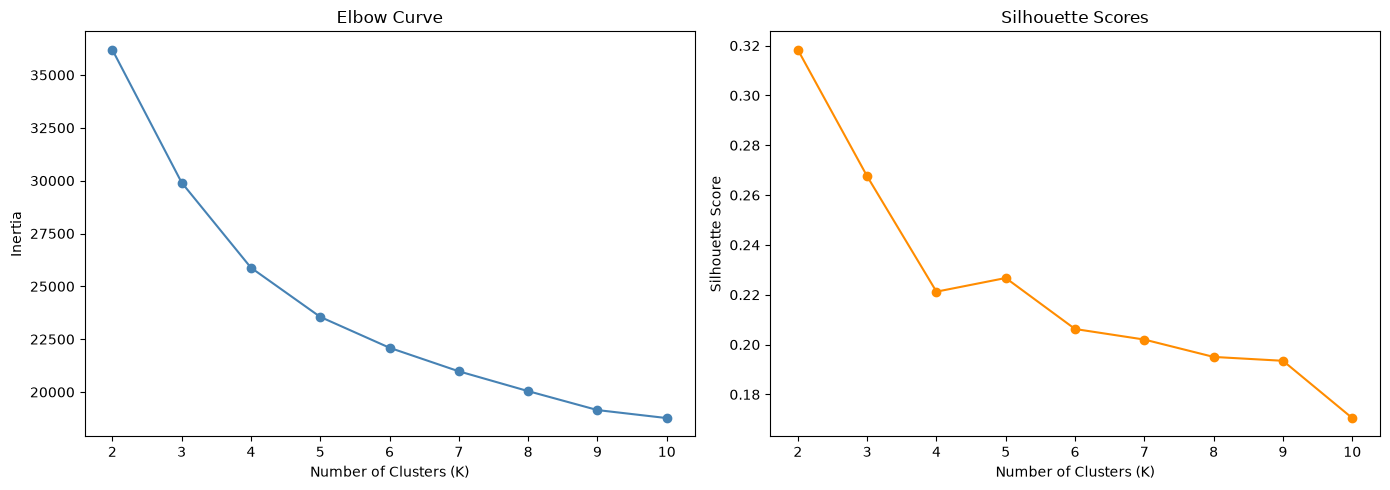

In [60]:
# plotting the curve to pick the best K
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# elbow curve
axes[0].plot(K_range, inertia, marker='o', color='steelblue')
axes[0].set_title('Elbow Curve')
axes[0].set_xlabel('Number of Clusters (K)')
axes[0].set_ylabel('Inertia')

# silhouette scores
axes[1].plot(K_range, silhouette_scores, marker='o', color='darkorange')
axes[1].set_title('Silhouette Scores')
axes[1].set_xlabel('Number of Clusters (K)')
axes[1].set_ylabel('Silhouette Score')

plt.tight_layout()
plt.savefig('../outputs/figures/elbow_silhouette.png', dpi=150, bbox_inches='tight')
plt.show()

### Selecting the Final K

The elbow curve shows a clear bend at K=4 where inertia reduction begins 
to flatten significantly. While K=2 produces the highest silhouette score, 
it results in only two patient groups which is too broad for meaningful 
clinical profiling. Therefore, K = 4 was selected to provide more detailed and meaningful patient segmentation while maintaining good clustering performance.

In [61]:
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df['cluster'] = kmeans.fit_predict(df_scaled.drop(columns=['stroke']))

In [62]:
cluster_profile = df.groupby('cluster')[['age', 'bmi', 'avg_glucose_level', 
                                          'hypertension', 'heart_disease', 
                                          'stroke']].mean().round(3)
cluster_profile

,age,bmi,avg_glucose_level,hypertension,heart_disease,stroke
cluster,,,,,,
0,8.437,19.241,93.938,0.000,0.000,0.000
1,31.892,28.779,91.570,0.034,0.004,0.006
2,60.859,31.139,86.514,0.141,0.085,0.076
3,60.955,32.789,196.091,0.235,0.147,0.128


### Cluster Profiles and Patient Personas

Four distinct patient groups emerged from the clustering analysis:

- **Cluster 0 — Young Children**: Average age 8, no risk factors, zero stroke rate
- **Cluster 1 — Healthy Young Adults**: Average age 32, minimal risk factors, 0.6% stroke rate  
- **Cluster 2 — Older Adults with Cardiovascular Risk**: Average age 61, elevated hypertension and heart disease, 7.6% stroke rate
- **Cluster 3 — High Risk Metabolic Patients**: Average age 61, high glucose, highest cardiovascular burden, 12.8% stroke rate

Clusters 2 and 3 share similar ages but differ significantly in glucose levels and cardiovascular burden, suggesting metabolic syndrome as a key differentiator for stroke risk among older patients.

### Visualizing Clusters using PCA


To better understand the structure of this dataset, applying **Principal Component Analysis (PCA)** will reduce the high‑dimensional feature space down to two dimensions.  
This dimensionality reduction allows us to create a 2D visualization that captures as much of the variance in the data as possible, making it easier to see whether distinct clusters or groupings emerge.


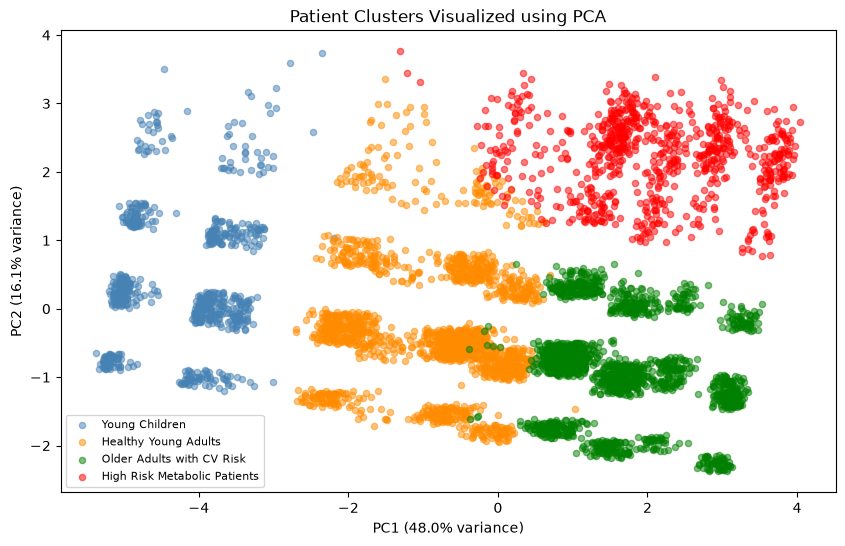

In [63]:
pca = PCA(n_components=2, random_state=42)
pca_coords = pca.fit_transform(df_scaled.drop(columns=['stroke']))

pca_df = pd.DataFrame(pca_coords, columns=['PC1', 'PC2'])
pca_df['cluster'] = df['cluster'].values

plt.figure(figsize=(10, 6))
colors = ['steelblue', 'darkorange', 'green', 'red']
cluster_names = {
    0: 'Young Children',
    1: 'Healthy Young Adults',
    2: 'Older Adults with CV Risk',
    3: 'High Risk Metabolic Patients'
}

for cluster in range(4):
    mask = pca_df['cluster'] == cluster
    plt.scatter(pca_df[mask]['PC1'], pca_df[mask]['PC2'],
                label=cluster_names[cluster],
                alpha=0.5, s=20, color=colors[cluster])

plt.title('Patient Clusters Visualized using PCA')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
plt.legend(fontsize=8)
plt.savefig('../outputs/figures/pca_clusters.png', dpi=150, bbox_inches='tight')
plt.show()

The PCA visualization confirms the four clusters are meaningfully separated 
in two dimensional space. PC1 (48% variance) primarily captures age-related 
separation where children sit far left while older patients sit right. PC2 (16.1% 
variance) appears to capture metabolic risk with high glucose patients (red) sit 
higher than cardiovascular risk patients (green) of similar age. Together the 
two components explain 64.1% of total variance, providing a reasonable 
two-dimensional view of the cluster structure.

In [64]:
# Trying to see what feature drives each component

pca_components = pd.DataFrame(
    pca.components_.T,
    index=df_scaled.drop(columns=['stroke']).columns,
    columns=['PC1', 'PC2']
).round(3)

print(pca_components.sort_values('PC1', ascending=False))

                                  PC1    PC2
age_bmi_risk                    0.688 -0.150
age                             0.394 -0.031
age_group                       0.391 -0.041
bmi_group                       0.296 -0.109
bmi                             0.224  0.021
ever_married                    0.140 -0.018
avg_glucose_level               0.139  0.700
glucose_group                   0.101  0.685
ever_smoked                     0.058 -0.006
work_type_self-employed         0.045 -0.005
work_type_private               0.044 -0.020
smoking_status_formerly smoked  0.039 -0.002
hypertension                    0.034  0.022
smoking_status_never smoked     0.030 -0.009
heart_disease                   0.023  0.015
smoking_status_smokes           0.020 -0.005
work_type_govt_job              0.020 -0.006
combined_condition              0.006  0.006
gender                         -0.001  0.022
Residence_type                 -0.001  0.003
work_type_never_worked         -0.002  0.000
smoking_st

### PCA Component Analysis

PC1 is clearly driven primarily by age-related features (**age_bmi_risk (0.688), age (0.394), and age_group (0.391)** ), highlighting age and body composition as the main sources of variation. The stronger contribution of the engineered feature *age_bmi_risk* compared to raw age validates the feature engineering choice.

PC2 is dominated by glucose-related features (**avg_glucose_level (0.700) and glucose_group (0.685)**), indicating metabolic risk as the secondary axis of variation. This explains why high-glucose patients (Cluster 3) appear higher than cardiovascular-risk patients (Cluster 2) despite similar ages.


##  Classification

Moving to supervised learning after Unsupervised (Clustering Analysis). The dataset is to be split into training and test sets, and at least three classifiers are going to be trained and evaluated.


In [65]:
# Defining my X and y

X = df.drop(columns=['stroke', 'cluster'])
y = df['stroke']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

print("Data has been split into X and y!")

(4087, 23)
(1022, 23)
(4087,)
(1022,)
Data has been split into X and y!


In [66]:
# Scaling continous features only
cols_to_scale = ['age', 'bmi', 'avg_glucose_level', 'age_bmi_risk']
scaler = StandardScaler()

X_train[cols_to_scale] = scaler.fit_transform(X_train[cols_to_scale])
X_test[cols_to_scale] = scaler.transform(X_test[cols_to_scale])

print("Continuous columns have been successfully scaled")

Continuous columns have been successfully scaled


In [67]:
# checking to see all features are scaled and encoded properly
X_train.head()

,gender,age,hypertension,heart_disease,ever_married,Residence_type,avg_glucose_level,bmi,age_group,glucose_group,bmi_group,age_bmi_risk,combined_condition,ever_smoked,work_type_children,work_type_govt_job,work_type_never_worked,work_type_private,work_type_self-employed,smoking_status_formerly smoked,smoking_status_never smoked,smoking_status_smokes,smoking_status_unknown
845,0,0.209397,0,0,1,0,-0.821221,0.549234,2,0,2,0.320001,0,0,0,0,0,1,0,0,1,0,0
3744,0,-0.629845,0,0,0,0,-0.485884,-0.988900,1,1,1,-0.933925,0,0,0,0,0,1,0,0,1,0,0
4183,0,-0.364822,0,0,1,1,0.302317,-0.769166,1,2,1,-0.933925,0,0,0,0,0,1,0,0,1,0,0
3409,1,-0.232310,0,0,1,1,0.062342,0.497532,1,2,2,-0.306962,0,0,0,0,0,1,0,0,1,0,0
284,1,-1.292405,0,0,0,0,-0.527297,0.355351,0,1,2,-0.933925,0,0,0,1,0,0,0,0,0,0,1


In [68]:
# Training the baseline model
lr_baseline = LogisticRegression(
    random_state=42,
    max_iter=1000
)
lr_baseline.fit(X_train, y_train)
print("The data has been successfully trained on a baseline model")

The data has been successfully trained on a baseline model


In [69]:
# making predictions on the trained data
y_pred = lr_baseline.predict(X_test)

y_prob = lr_baseline.predict_proba(X_test)[:,1]


In [70]:
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(roc_auc_score(y_test, y_prob))

              precision    recall  f1-score   support

           0       0.95      1.00      0.98       972
           1       1.00      0.02      0.04        50

    accuracy                           0.95      1022
   macro avg       0.98      0.51      0.51      1022
weighted avg       0.95      0.95      0.93      1022

[[972   0]
 [ 49   1]]
0.8421810699588478


In [71]:
# training a model with class weight = balanced
lr_balanced = LogisticRegression(
    class_weight='balanced',
    random_state=42,
    max_iter= 1000
)
lr_balanced.fit(X_train, y_train)
print("The data has been successfully trained on a logistic regression model with class weight = balanced")

The data has been successfully trained on a logistic regression model with class weight = balanced


In [72]:
# making predictions on the trained data
y_pred_balanced = lr_balanced.predict(X_test)
y_prob_balanced = lr_balanced.predict_proba(X_test)[:,1]

In [73]:
print(classification_report(y_test, y_pred_balanced))
print(confusion_matrix(y_test, y_pred_balanced))
print(roc_auc_score(y_test, y_prob_balanced))

              precision    recall  f1-score   support

           0       0.99      0.74      0.85       972
           1       0.14      0.80      0.23        50

    accuracy                           0.74      1022
   macro avg       0.56      0.77      0.54      1022
weighted avg       0.94      0.74      0.82      1022

[[719 253]
 [ 10  40]]
0.8443415637860082


The baseline Logistic Regression is not suitable because it missed 98% of stroke cases (recall = 0.02).
The class-weighted Logistic Regression is much better for a healthcare screening task because it identified 80% of stroke cases, although it does so at the cost of many false positives.
More models would be trained to see which produces the better results.

In [74]:
# training a random forest classifier
rf_baseline = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1,
    min_samples_split=2,
    min_samples_leaf=1
)
rf_baseline.fit(X_train, y_train)
print("The data has been successfully trained on a random forest classifier model")


The data has been successfully trained on a random forest classifier model
